# Project Title

# 🌱 Crop Recommendation System - Exploratory Data Analysis (EDA)

## Objective
Analyze the crop recommendation dataset to understand:
- Dataset structure
- Missing values
- Duplicate values
- Feature distributions
- Correlation
- Target class distribution

# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

# Load Dataset

In [3]:
df = pd.read_csv("../data/raw/Crop_recommendation.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# Dataset Shape

In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 2200
Columns : 8


# Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


# Statistical Summary

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


# Check Missing Values

In [8]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

# Check Duplicate Rows

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Display Columns

In [10]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

# Target Classes

In [11]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

# Dataset Summary

In [12]:
print(df.describe())

                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117  


# Plot Histograms

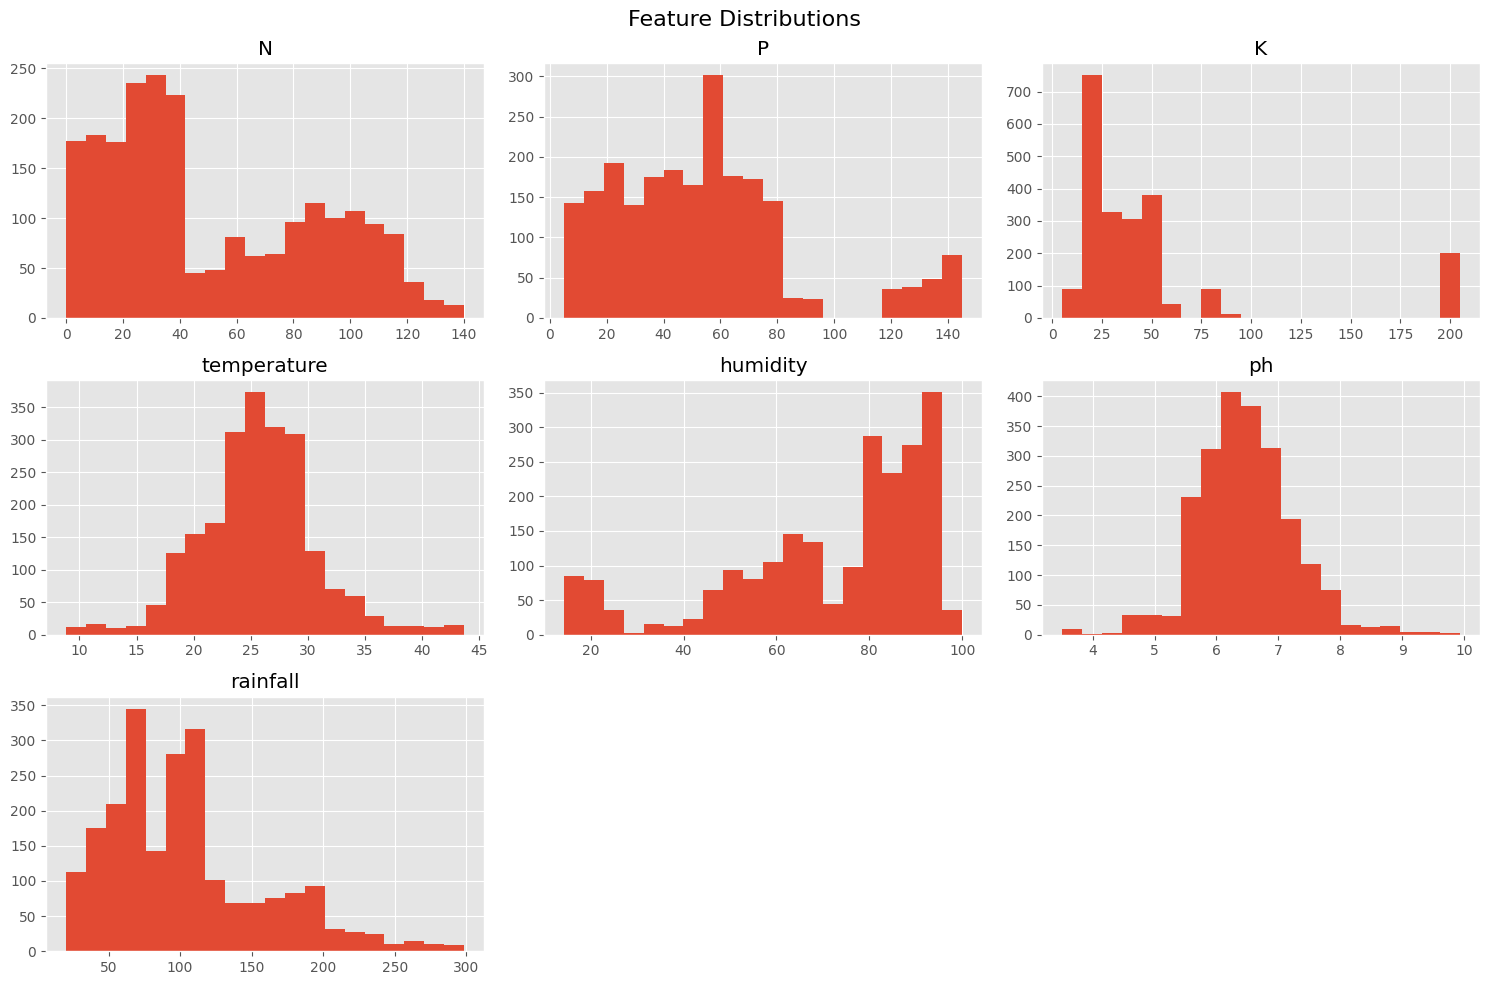

In [13]:
df.hist(figsize=(15, 10), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

# Boxplots (Outlier Detection)

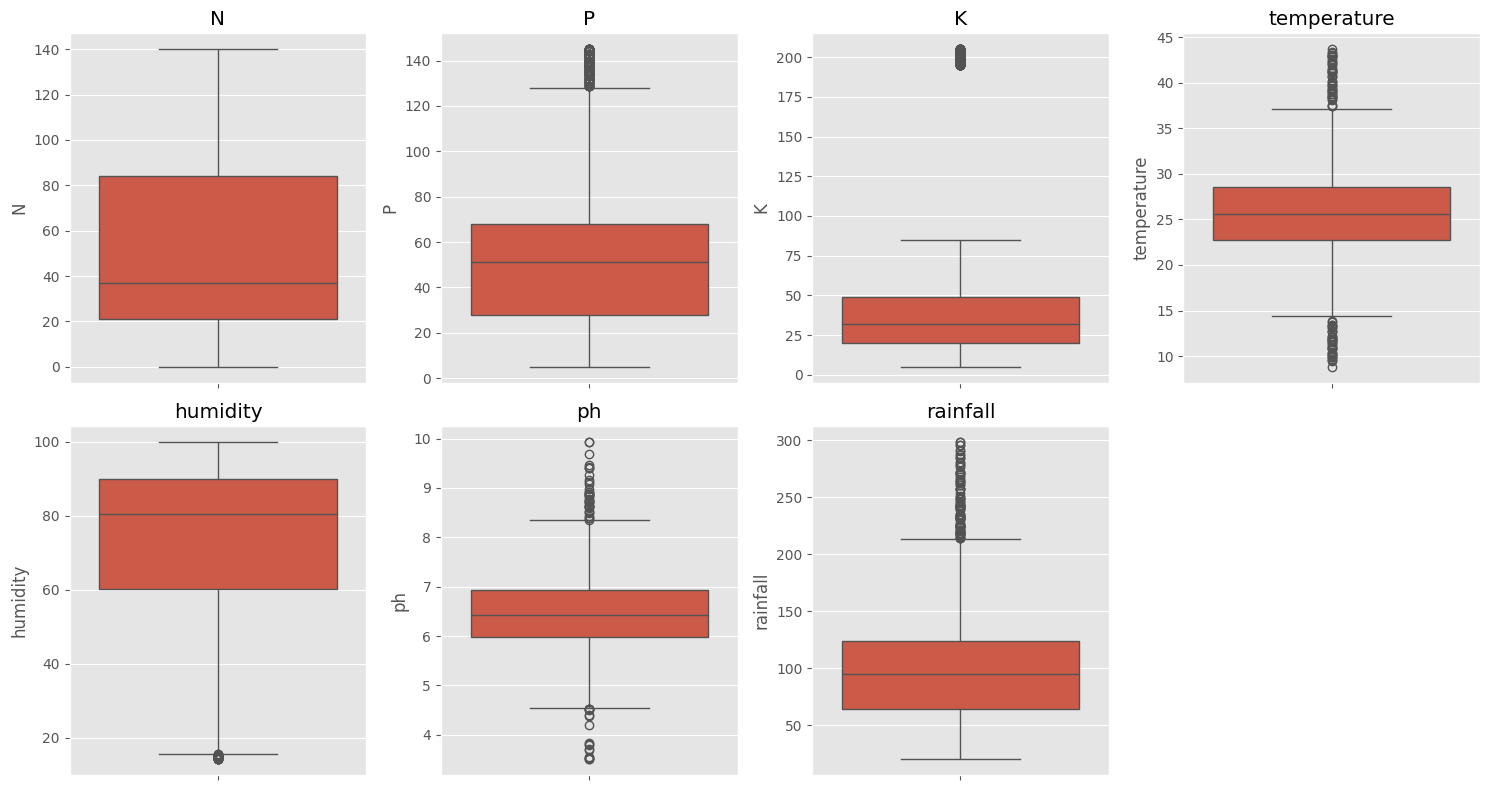

In [14]:
plt.figure(figsize=(15,8))

for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

# Correlation Heatmap

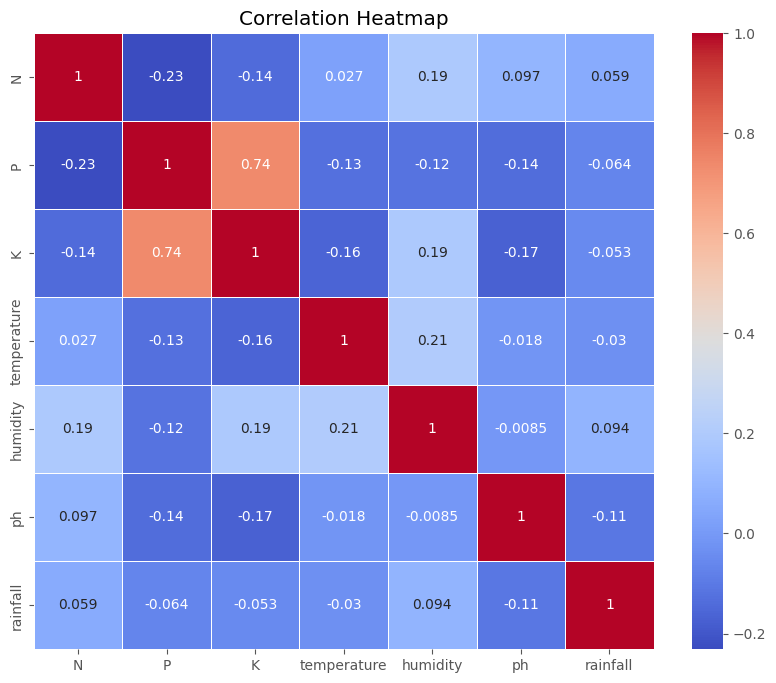

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("label", axis=1).corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# Target Class Distribution

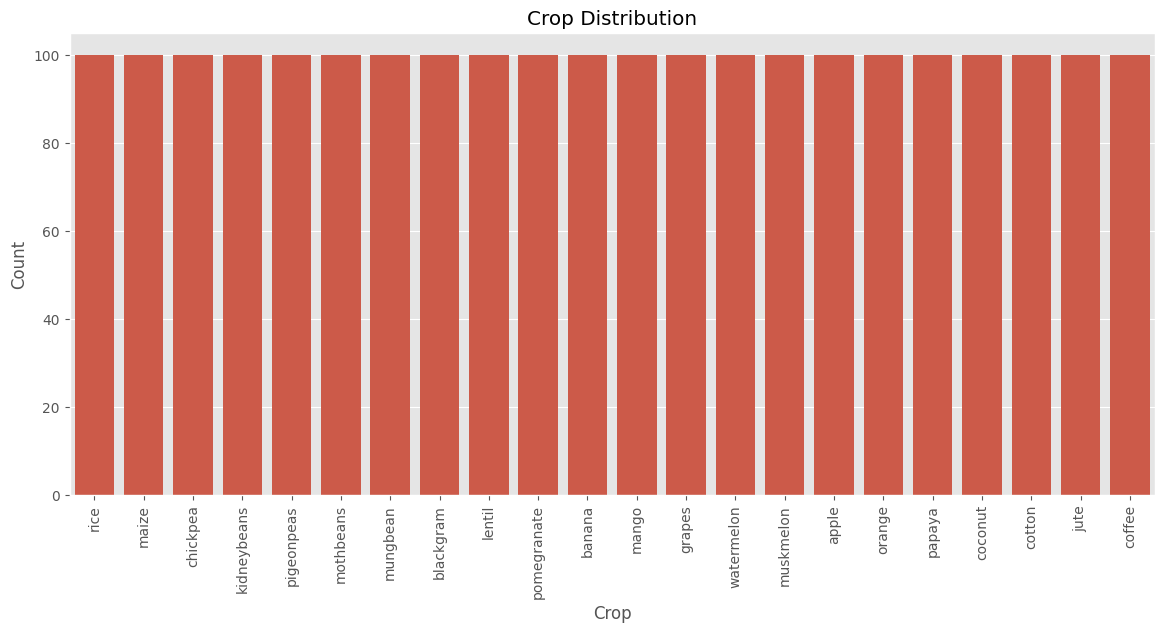

In [16]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.show()

# Pairplot

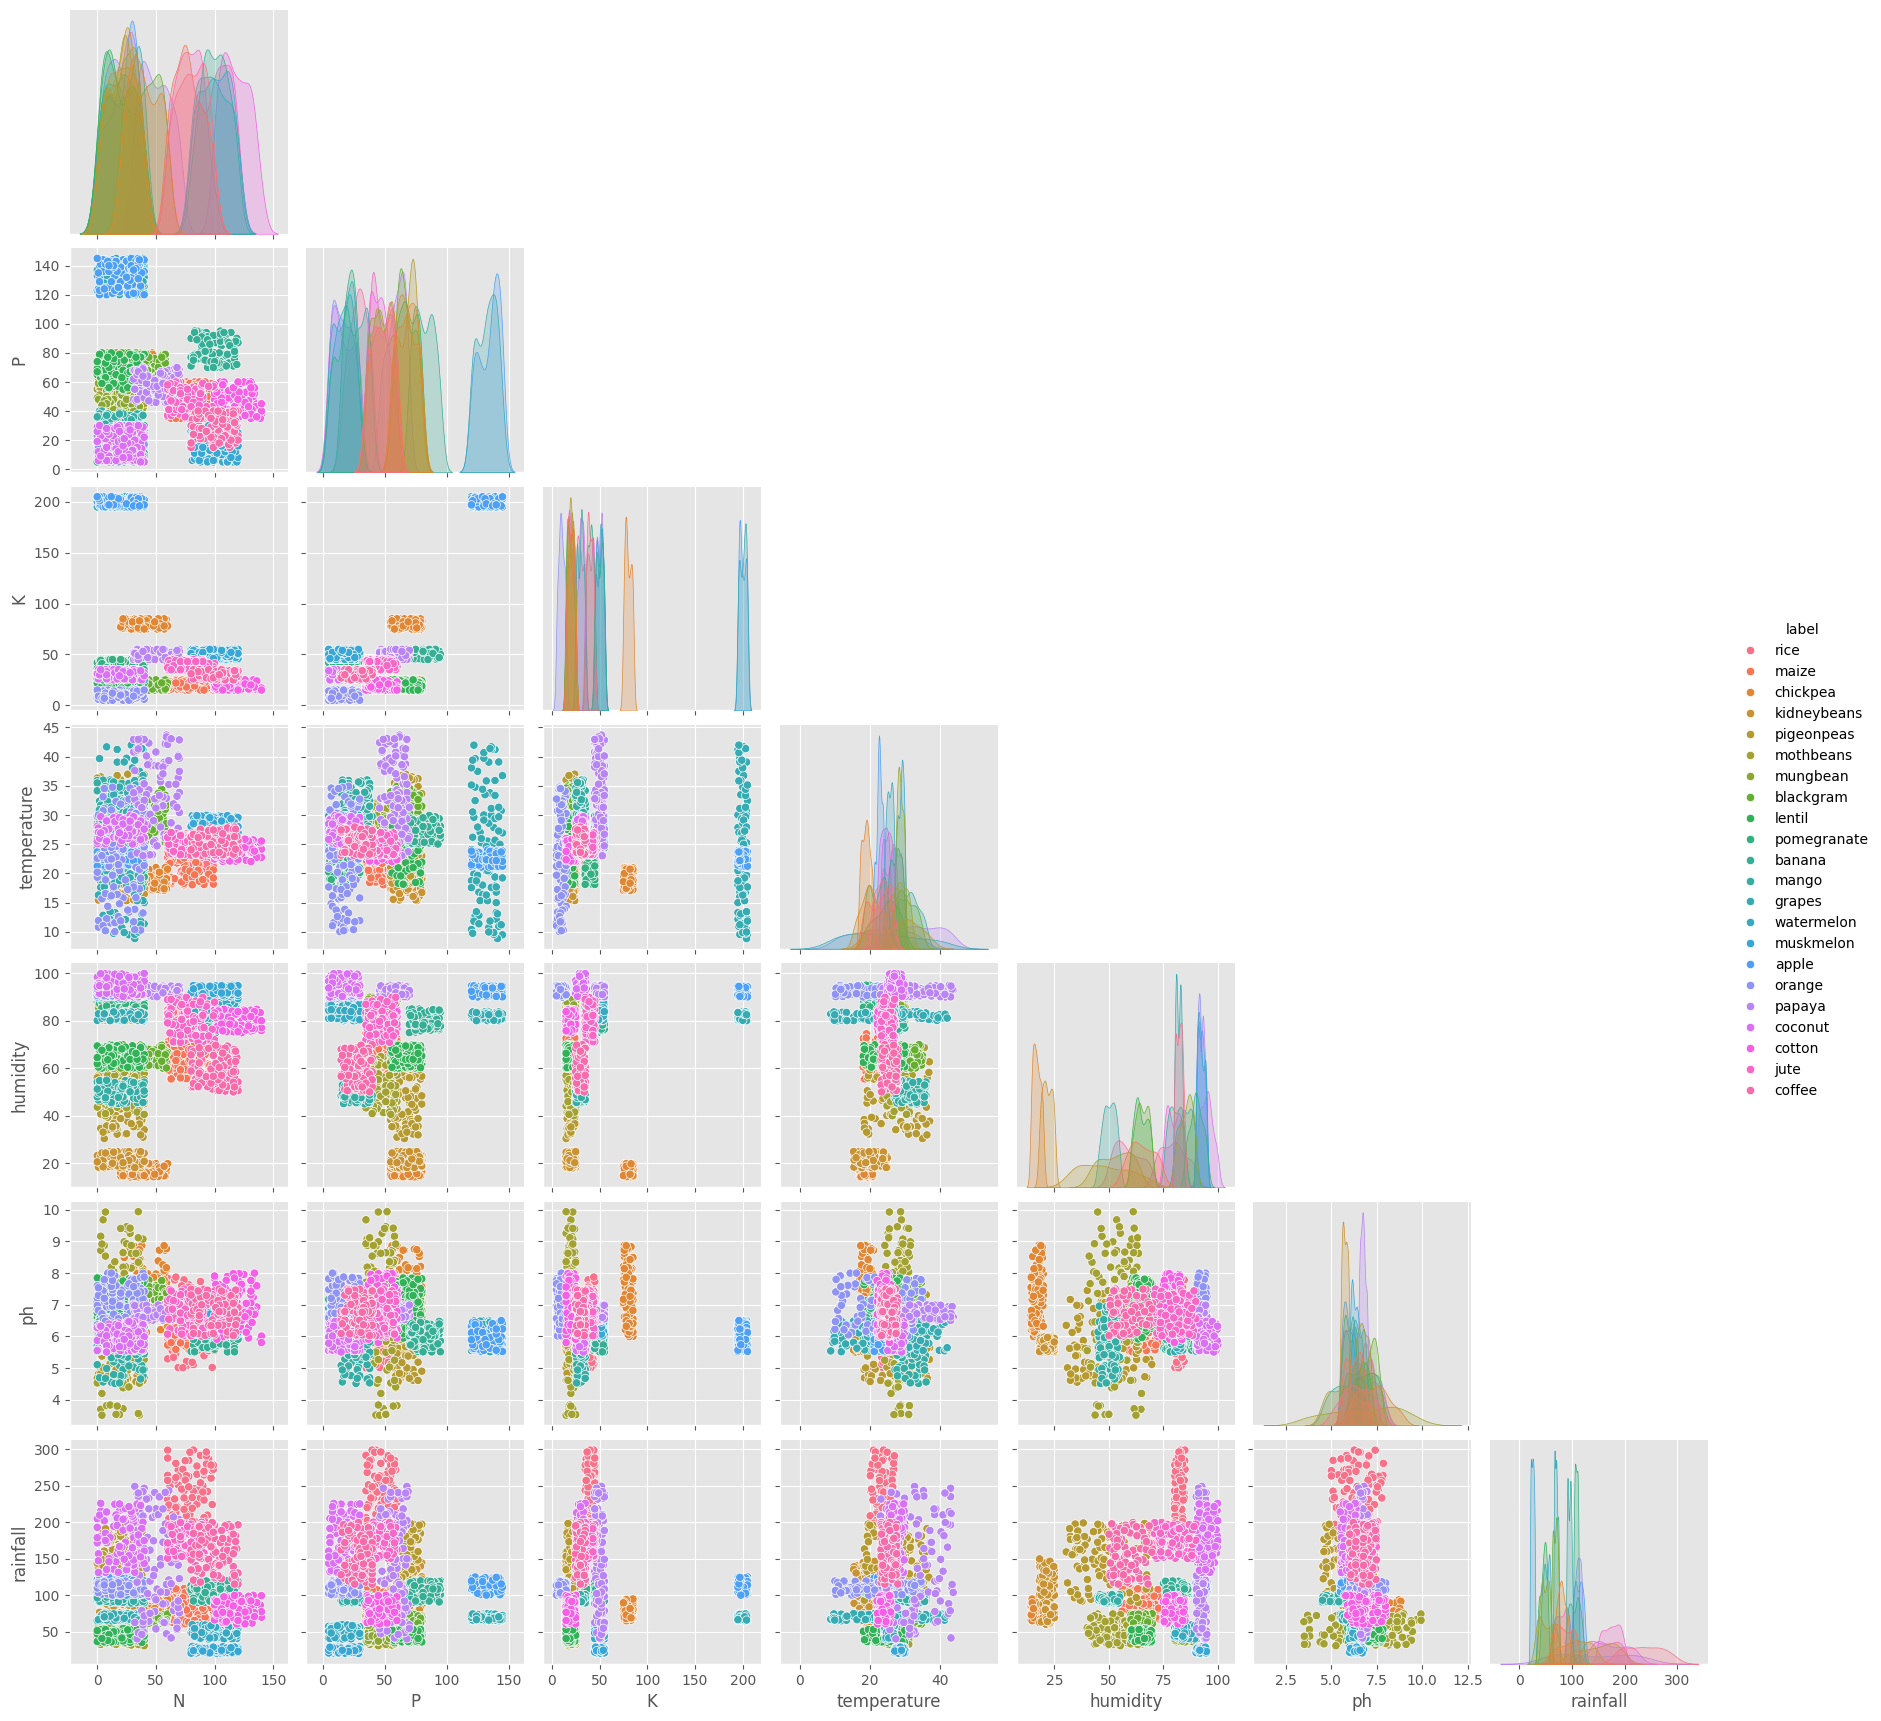

In [18]:
sns.pairplot(
    df,
    hue="label",
    corner=True
)

plt.show()

# Feature Distributions (KDE)

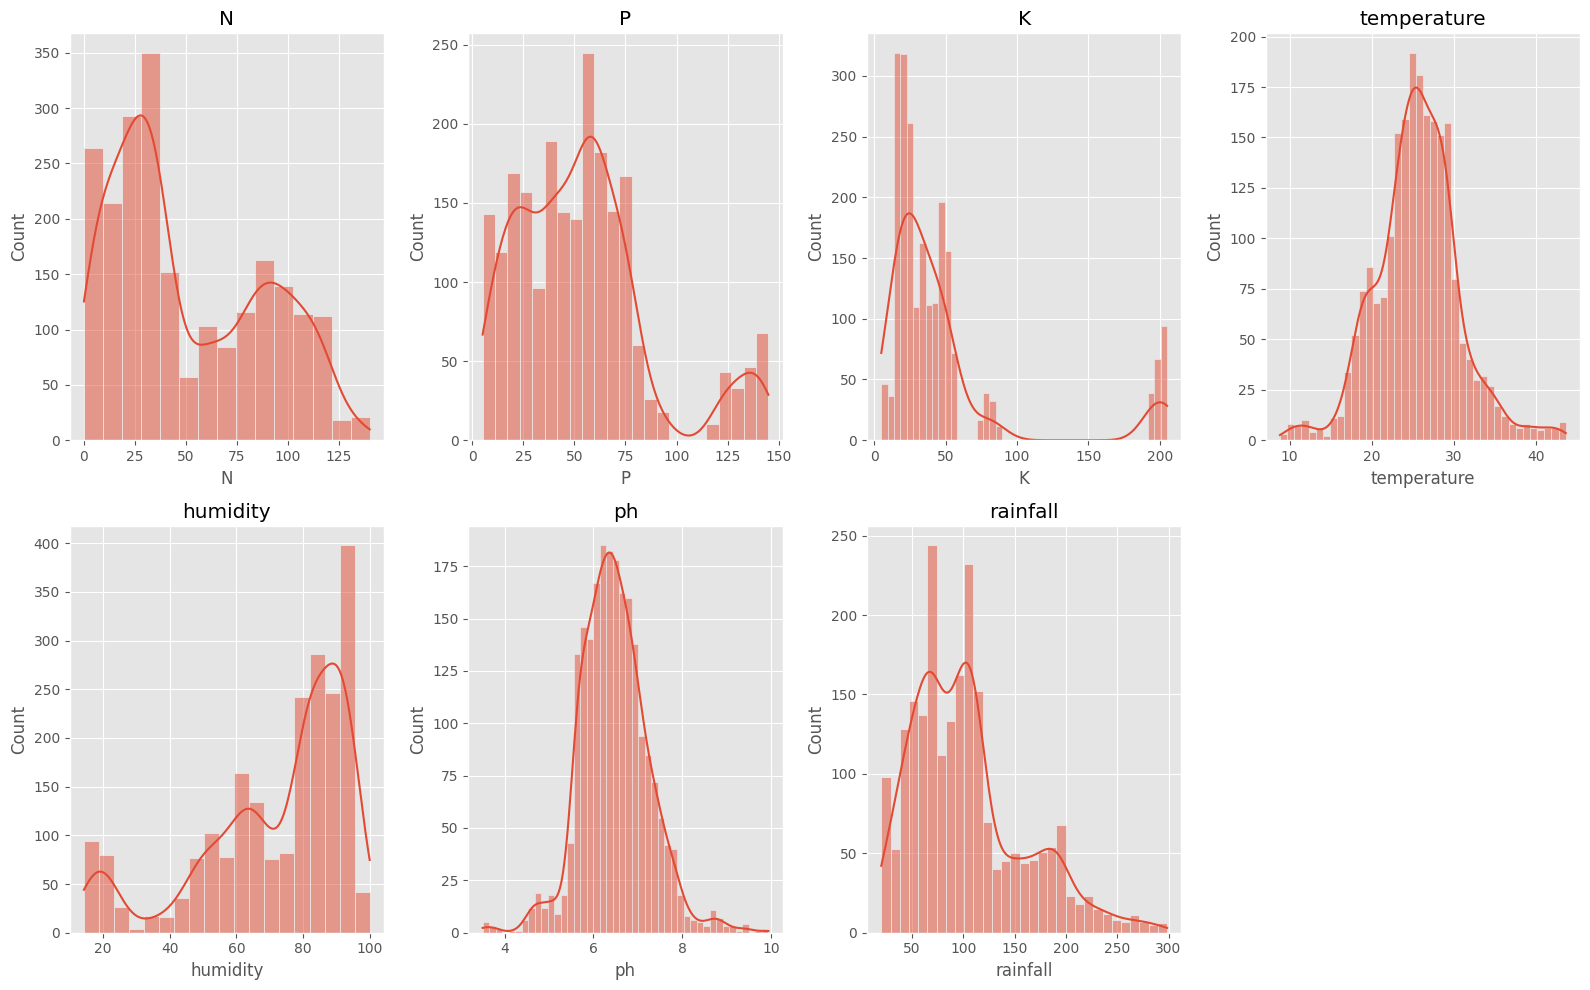

In [19]:
features = df.columns[:-1]

plt.figure(figsize=(16,10))

for i, feature in enumerate(features):
    plt.subplot(2,4,i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(feature)

plt.tight_layout()
plt.show()

# Crop Frequency Table

In [20]:
crop_counts = df["label"].value_counts().reset_index()
crop_counts.columns = ["Crop", "Count"]

crop_counts

,Crop,Count
0,rice,100
1,maize,100
2,chickpea,100
3,kidneybeans,100
4,pigeonpeas,100
5,mothbeans,100
6,mungbean,100
7,blackgram,100
8,lentil,100
9,pomegranate,100


# Correlation Matrix Table

In [21]:
corr = df.drop("label", axis=1).corr()

corr

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


# Key Findings

## Dataset Summary

- The dataset contains **2200 observations** and **8 columns**.
- There are **no missing values**.
- There are **no duplicate records**.
- The target variable contains **22 crop classes**.
- Each crop has **100 samples**, making the dataset perfectly balanced.

## Feature Analysis

- Temperature follows an approximately normal distribution.
- Soil pH is concentrated around 6–7, which is suitable for many crops.
- Rainfall shows a positively skewed distribution.
- Humidity values are concentrated between 70% and 95%.
- Nitrogen, Phosphorus, and Potassium exhibit wider variability.

## Correlation Analysis

- Phosphorus and Potassium show a strong positive correlation (~0.74).
- Temperature and Humidity have only a weak positive correlation.
- Most features exhibit low correlation, reducing the risk of multicollinearity.

## Outlier Analysis

- Boxplots indicate the presence of outliers in Potassium, Rainfall, and Temperature.
- These values appear to represent genuine agricultural conditions rather than data errors and will be retained.

## Conclusion

The dataset is clean, balanced, and well-suited for machine learning classification tasks.

In [23]:
import os
# Save processed dataset
df.to_csv("../data/processed/crop_processed.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
